In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

DATA_PATH = '/content/drive/MyDrive/Colab Notebooks/Data/instacart-basket-analysis/'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Import libraries
import pandas as pd
import numpy as np

pd.set_option('display.max_columns', None)
print("Libraries loaded!")

Libraries loaded!


In [ ]:
# Load all datasets
orders = pd.read_csv(DATA_PATH + 'orders.csv')
order_products_prior = pd.read_csv(DATA_PATH + 'order_products__prior.csv')
order_products_train = pd.read_csv(DATA_PATH + 'order_products__train.csv')
products = pd.read_csv(DATA_PATH + 'products.csv')
aisles = pd.read_csv(DATA_PATH + 'aisles.csv')
departments = pd.read_csv(DATA_PATH + 'departments.csv')

print("All datasets loaded!")
print(f"Orders: {orders.shape}")
print(f"Order Products (Prior): {order_products_prior.shape}")
print(f"Order Products (Train): {order_products_train.shape}")
print(f"Products: {products.shape}")
print(f"Aisles: {aisles.shape}")
print(f"Departments: {departments.shape}")

All datasets loaded!
Orders: (3421083, 7)
Order Products (Prior): (32434489, 4)
Order Products (Train): (1384617, 4)
Products: (49688, 4)
Aisles: (134, 2)
Departments: (21, 2)


In [ ]:
# Preview each table
datasets = {
    'orders': orders,
    'order_products_prior': order_products_prior,
    'order_products_train': order_products_train,
    'products': products,
    'aisles': aisles,
    'departments': departments
}

for name, df in datasets.items():
    print(f"\n{'='*60}")
    print(f"{name} — {df.shape[0]:,} rows, {df.shape[1]} columns")
    print(f"{'='*60}")
    print(df.dtypes)
    print(f"\nMissing values:\n{df.isnull().sum()}")
    print(f"\nFirst 3 rows:")
    display(df.head(3))


orders — 3,421,083 rows, 7 columns
order_id                    int64
user_id                     int64
eval_set                   object
order_number                int64
order_dow                   int64
order_hour_of_day           int64
days_since_prior_order    float64
dtype: object

Missing values:
order_id                       0
user_id                        0
eval_set                       0
order_number                   0
order_dow                      0
order_hour_of_day              0
days_since_prior_order    206209
dtype: int64

First 3 rows:


,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2539329,1,prior,1,2,8,NaN
1,2398795,1,prior,2,3,7,15.0
2,473747,1,prior,3,3,12,21.0



order_products_prior — 32,434,489 rows, 4 columns
order_id             int64
product_id           int64
add_to_cart_order    int64
reordered            int64
dtype: object

Missing values:
order_id             0
product_id           0
add_to_cart_order    0
reordered            0
dtype: int64

First 3 rows:


,order_id,product_id,add_to_cart_order,reordered
0,2,33120,1,1
1,2,28985,2,1
2,2,9327,3,0



order_products_train — 1,384,617 rows, 4 columns
order_id             int64
product_id           int64
add_to_cart_order    int64
reordered            int64
dtype: object

Missing values:
order_id             0
product_id           0
add_to_cart_order    0
reordered            0
dtype: int64

First 3 rows:


...

,product_id,product_name,aisle_id,department_id
0,1,Chocolate Sandwich Cookies,61,19
1,2,All-Seasons Salt,104,13
2,3,Robust Golden Unsweetened Oolong Tea,94,7



aisles — 134 rows, 2 columns
aisle_id     int64
aisle       object
dtype: object

Missing values:
aisle_id    0
aisle       0
dtype: int64

First 3 rows:


,aisle_id,aisle
0,1,prepared soups salads
1,2,specialty cheeses
2,3,energy granola bars



departments — 21 rows, 2 columns
department_id     int64
department       object
dtype: object

Missing values:
department_id    0
department       0
dtype: int64

First 3 rows:


,department_id,department
0,1,frozen
1,2,other
2,3,bakery


In [ ]:
# Verify: NaN in days_since_prior_order = first order?
print("=== Verify Missing Values ===")
print(f"Total NaN in days_since_prior_order: {orders['days_since_prior_order'].isnull().sum():,}")
print(f"Total orders with order_number = 1: {(orders['order_number'] == 1).sum():,}")
print(f"Match: {orders['days_since_prior_order'].isnull().sum() == (orders['order_number'] == 1).sum()}")

print("\n=== Orders Summary Stats ===")
print(f"Unique users: {orders['user_id'].nunique():,}")
print(f"Unique orders: {orders['order_id'].nunique():,}")
print(f"Orders per user: {orders.groupby('user_id')['order_id'].count().describe().round(1).to_string()}")

print("\n=== Eval Set Distribution ===")
print(orders['eval_set'].value_counts())

print("\n=== days_since_prior_order Stats ===")
print(orders['days_since_prior_order'].describe().round(1))

=== Verify Missing Values ===
Total NaN in days_since_prior_order: 206,209
Total orders with order_number = 1: 206,209
Match: True

=== Orders Summary Stats ===
Unique users: 206,209
Unique orders: 3,421,083
Orders per user: count    206209.0
mean         16.6
std          16.7
min           4.0
25%           6.0
50%          10.0
75%          20.0
max         100.0

=== Eval Set Distribution ===
eval_set
prior    3214874
train     131209
test       75000
Name: count, dtype: int64

=== days_since_prior_order Stats ===
count    3214874.0
mean          11.1
std            9.2
min            0.0
25%            4.0
50%            7.0
75%           15.0
max           30.0
Name: days_since_prior_order, dtype: float64


### Dataset Overview
| Table | Rows | Columns | Description |
|-------|------|---------|-------------|
| orders | 3,421,083 | 7 | Order-level data with timing info |
| order_products_prior | 32,434,489 | 4 | Line items for prior orders |
| order_products_train | 1,384,617 | 4 | Line items for train orders |
| products | 49,688 | 4 | Product names + category mapping |
| aisles | 134 | 2 | Aisle dimension |
| departments | 21 | 2 | Department dimension |

### Key Findings
- **206,209 unique users**, each with 4–100 orders (avg ~17)
- **Missing values**: Only `days_since_prior_order` has 206,209 NaN = first orders (expected, no action needed)
- **Reorder cycle**: Median 7 days between orders, max 30 days
- **Scope**: We will use `prior` orders (3.2M) as the main analytical dataset

In [ ]:
# Verify join keys
print("=== Join Key Validation ===\n")

# orders <-> order_products_prior
prior_orders = set(order_products_prior['order_id'].unique())
all_prior_order_ids = set(orders[orders['eval_set'] == 'prior']['order_id'].unique())
print(f"order_products_prior order_ids match prior orders: {prior_orders.issubset(all_prior_order_ids)}")

# order_products <-> products
prior_product_ids = set(order_products_prior['product_id'].unique())
all_product_ids = set(products['product_id'].unique())
print(f"All product_ids in prior exist in products table: {prior_product_ids.issubset(all_product_ids)}")

# products <-> aisles & departments
print(f"All aisle_ids in products exist in aisles: {set(products['aisle_id'].unique()).issubset(set(aisles['aisle_id'].unique()))}")
print(f"All department_ids in products exist in departments: {set(products['department_id'].unique()).issubset(set(departments['department_id'].unique()))}")

print("\n=== Schema ===")
print("orders --(order_id)--> order_products_prior --(product_id)--> products --(aisle_id)--> aisles")
print("                                                              products --(department_id)--> departments")

=== Join Key Validation ===

order_products_prior order_ids match prior orders: True
All product_ids in prior exist in products table: True
All aisle_ids in products exist in aisles: True
All department_ids in products exist in departments: True

=== Schema ===
orders --(order_id)--> order_products_prior --(product_id)--> products --(aisle_id)--> aisles
                                                              products --(department_id)--> departments


In [ ]:
# Filter only prior orders
orders_prior = orders[orders['eval_set'] == 'prior'].copy()
print(f"Prior orders: {orders_prior.shape[0]:,}")

# Join: order_products_prior + products + aisles + departments
df = (
    order_products_prior
    .merge(products, on='product_id', how='left')
    .merge(aisles, on='aisle_id', how='left')
    .merge(departments, on='department_id', how='left')
)
print(f"After product join: {df.shape[0]:,} rows")

# Join with orders (to get user_id, order timing)
df = df.merge(orders_prior[['order_id', 'user_id', 'order_number', 'order_dow', 'order_hour_of_day', 'days_since_prior_order']],
              on='order_id', how='left')

print(f"\nFinal analytical dataset: {df.shape[0]:,} rows, {df.shape[1]} columns")
print(f"Columns: {list(df.columns)}")
df.head()

Prior orders: 3,214,874
After product join: 32,434,489 rows

Final analytical dataset: 32,434,489 rows, 14 columns
Columns: ['order_id', 'product_id', 'add_to_cart_order', 'reordered', 'product_name', 'aisle_id', 'department_id', 'aisle', 'department', 'user_id', 'order_number', 'order_dow', 'order_hour_of_day', 'days_since_prior_order']


,order_id,product_id,add_to_cart_order,reordered,product_name,aisle_id,department_id,aisle,department,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2,33120,1,1,Organic Egg Whites,86,16,eggs,dairy eggs,202279,3,5,9,8.0
1,2,28985,2,1,Michigan Organic Kale,83,4,fresh vegetables,produce,202279,3,5,9,8.0
2,2,9327,3,0,Garlic Powder,104,13,spices seasonings,pantry,202279,3,5,9,8.0
3,2,45918,4,1,Coconut Butter,19,13,oils vinegars,pantry,202279,3,5,9,8.0
4,2,30035,5,0,Natural Sweetener,17,13,baking ingredients,pantry,202279,3,5,9,8.0


In [ ]:
# Check duplicates
print(f"Duplicate rows: {df.duplicated().sum():,}")
print(f"Null values:\n{df.isnull().sum()}")
print(f"\n=== Final Dataset Stats ===")
print(f"Unique users: {df['user_id'].nunique():,}")
print(f"Unique orders: {df['order_id'].nunique():,}")
print(f"Unique products: {df['product_id'].nunique():,}")
print(f"Unique aisles: {df['aisle'].nunique()}")
print(f"Unique departments: {df['department'].nunique()}")

Duplicate rows: 0
Null values:
order_id                        0
product_id                      0
add_to_cart_order               0
reordered                       0
product_name                    0
aisle_id                        0
department_id                   0
aisle                           0
department                      0
user_id                         0
order_number                    0
order_dow                       0
order_hour_of_day               0
days_since_prior_order    2078068
dtype: int64

=== Final Dataset Stats ===
Unique users: 206,209
Unique orders: 3,214,874
Unique products: 49,677
Unique aisles: 134
Unique departments: 21


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12

# Use the analytical dataset from Cell 8
print(f"Analytical dataset ready: {df.shape[0]:,} rows")

Analytical dataset ready: 32,434,489 rows


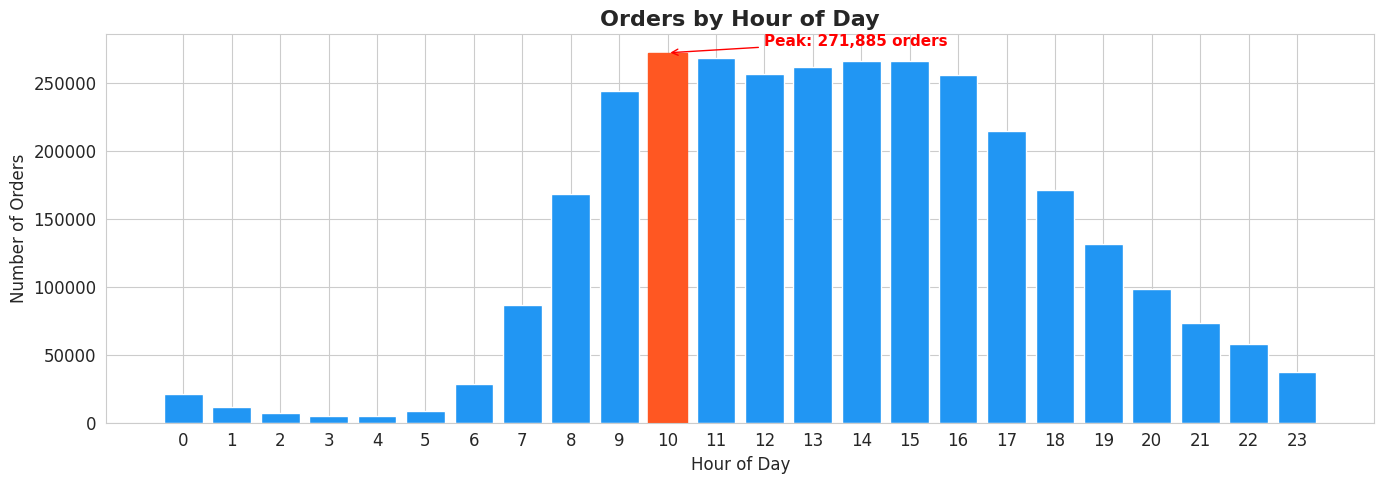


Peak hour: 10:00
Top 5 hours:
 hour  total_orders
   10        271885
   11        268006
   15        266132
   14        265556
   13        261174


In [ ]:
# When do customers shop?
hourly = df.groupby('order_hour_of_day')['order_id'].nunique().reset_index()
hourly.columns = ['hour', 'total_orders']

plt.figure(figsize=(14, 5))
bars = plt.bar(hourly['hour'], hourly['total_orders'], color='#2196F3', edgecolor='white')

# Highlight peak hours
peak_hour = hourly.loc[hourly['total_orders'].idxmax(), 'hour']
bars[peak_hour].set_color('#FF5722')

plt.title('Orders by Hour of Day', fontsize=16, fontweight='bold')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Orders')
plt.xticks(range(0, 24))

# Add peak annotation
peak_val = hourly['total_orders'].max()
plt.annotate(f'Peak: {peak_val:,} orders',
             xy=(peak_hour, peak_val),
             xytext=(peak_hour+2, peak_val+5000),
             arrowprops=dict(arrowstyle='->', color='red'),
             fontsize=11, color='red', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nPeak hour: {peak_hour}:00")
print(f"Top 5 hours:")
print(hourly.nlargest(5, 'total_orders').to_string(index=False))

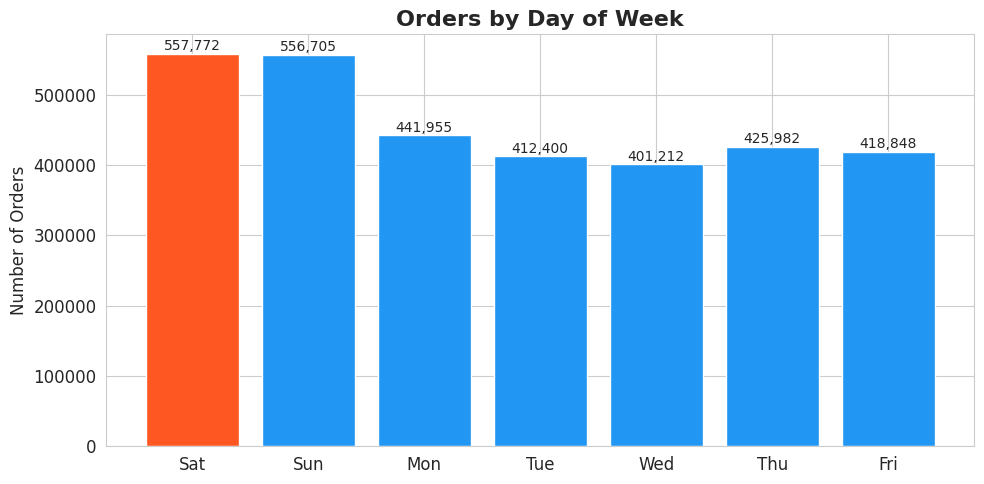

In [ ]:
# Day of week mapping (0=Saturday based on Instacart data)
day_labels = {0: 'Sat', 1: 'Sun', 2: 'Mon', 3: 'Tue', 4: 'Wed', 5: 'Thu', 6: 'Fri'}

daily = df.groupby('order_dow')['order_id'].nunique().reset_index()
daily.columns = ['dow', 'total_orders']
daily['day_name'] = daily['dow'].map(day_labels)

plt.figure(figsize=(10, 5))
colors = ['#FF5722' if x == daily['total_orders'].max() else '#2196F3' for x in daily['total_orders']]
plt.bar(daily['day_name'], daily['total_orders'], color=colors, edgecolor='white')

plt.title('Orders by Day of Week', fontsize=16, fontweight='bold')
plt.ylabel('Number of Orders')

for i, v in enumerate(daily['total_orders']):
    plt.text(i, v + 5000, f'{v:,}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

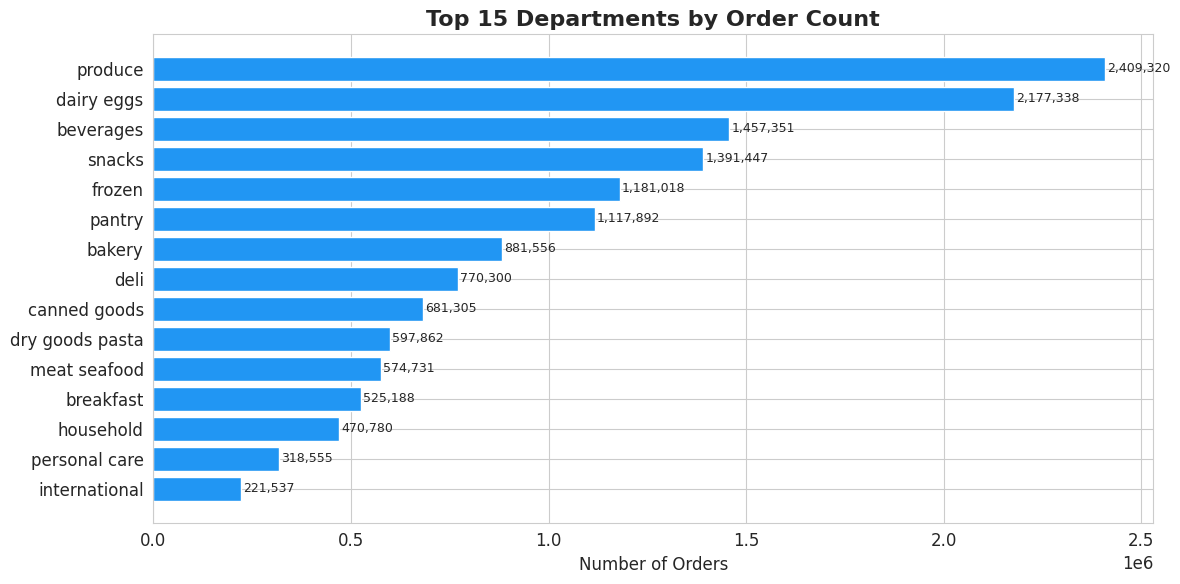

In [ ]:
dept_orders = df.groupby('department')['order_id'].nunique().nlargest(15).reset_index()
dept_orders.columns = ['department', 'total_orders']

plt.figure(figsize=(12, 6))
plt.barh(dept_orders['department'][::-1], dept_orders['total_orders'][::-1], color='#2196F3', edgecolor='white')
plt.title('Top 15 Departments by Order Count', fontsize=16, fontweight='bold')
plt.xlabel('Number of Orders')

for i, v in enumerate(dept_orders['total_orders'][::-1]):
    plt.text(v + 5000, i, f'{v:,}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

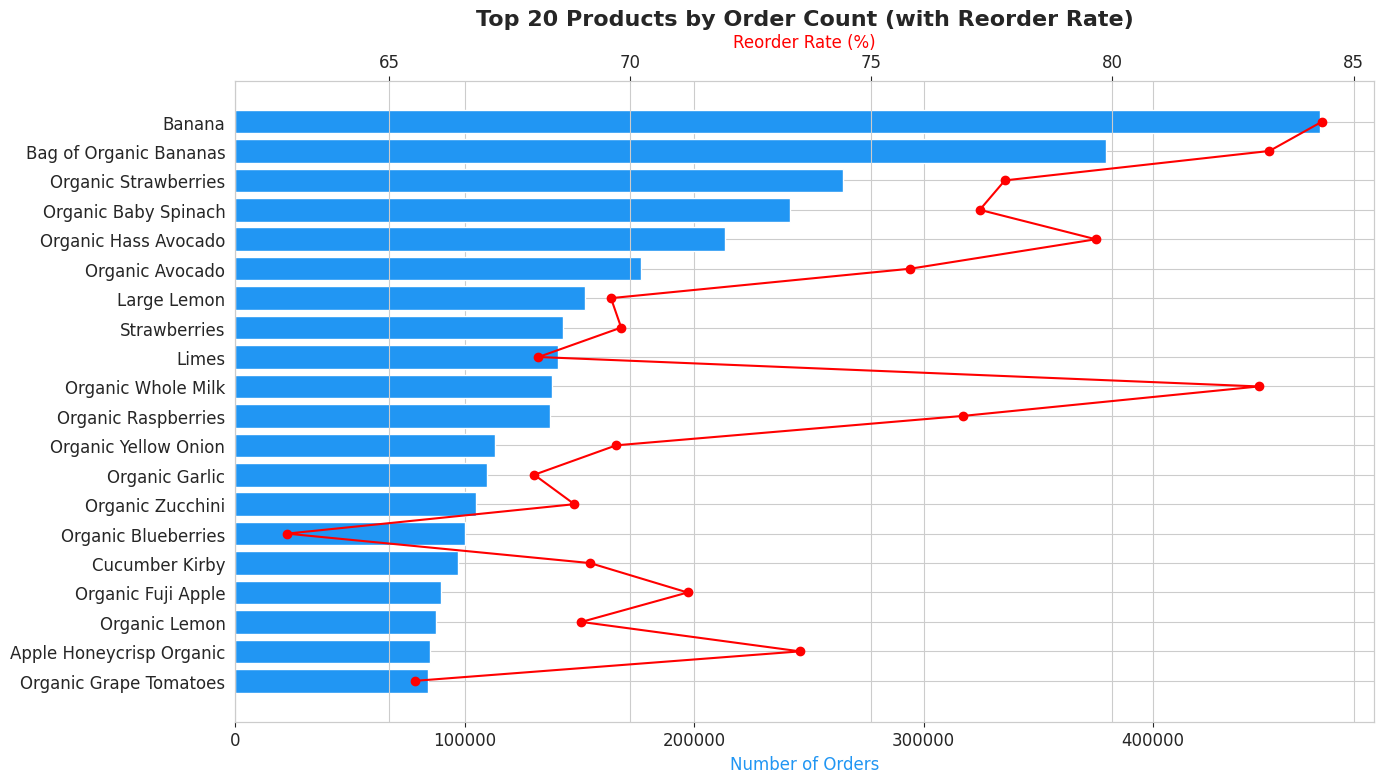


Top 20 Products:
                 Product  Orders  Reorder Rate (%)
                  Banana  472565              84.4
  Bag of Organic Bananas  379450              83.3
    Organic Strawberries  264683              77.8
    Organic Baby Spinach  241921              77.3
    Organic Hass Avocado  213584              79.7
         Organic Avocado  176815              75.8
             Large Lemon  152657              69.6
            Strawberries  142951              69.8
                   Limes  140627              68.1
      Organic Whole Milk  137905              83.0
     Organic Raspberries  137057              76.9
    Organic Yellow Onion  113426              69.7
          Organic Garlic  109778              68.0
        Organic Zucchini  104823              68.8
     Organic Blueberries  100060              62.9
          Cucumber Kirby   97315              69.2
      Organic Fuji Apple   89632              71.2
           Organic Lemon   87746              69.0
Apple Honeycr

In [ ]:
top_products = df.groupby('product_name').agg(
    order_count=('order_id', 'nunique'),
    reorder_rate=('reordered', 'mean')
).nlargest(20, 'order_count').reset_index()

fig, ax1 = plt.subplots(figsize=(14, 8))

# Bar chart - order count
bars = ax1.barh(top_products['product_name'][::-1], top_products['order_count'][::-1], color='#2196F3', edgecolor='white')
ax1.set_xlabel('Number of Orders', color='#2196F3')
ax1.set_title('Top 20 Products by Order Count (with Reorder Rate)', fontsize=16, fontweight='bold')

# Second axis - reorder rate
ax2 = ax1.twiny()
ax2.plot(top_products['reorder_rate'][::-1] * 100, top_products['product_name'][::-1], 'ro-', markersize=6)
ax2.set_xlabel('Reorder Rate (%)', color='red')

plt.tight_layout()
plt.show()

# Print table
print("\nTop 20 Products:")
top_products['reorder_rate'] = (top_products['reorder_rate'] * 100).round(1)
top_products.columns = ['Product', 'Orders', 'Reorder Rate (%)']
print(top_products.to_string(index=False))

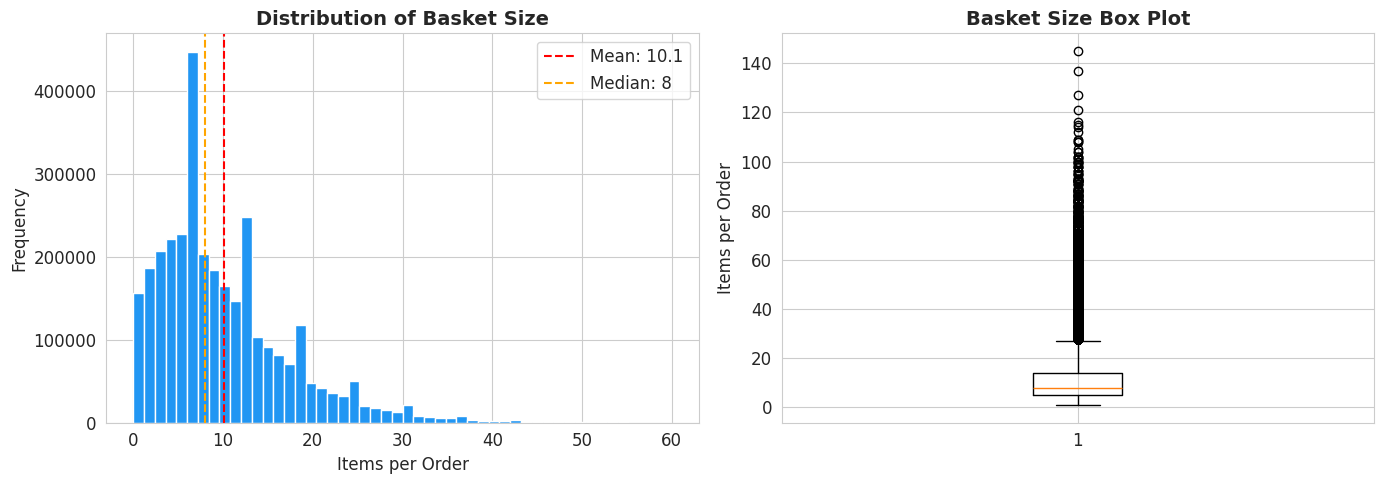


Basket Size Stats:
count    3214874.0
mean          10.1
std            7.5
min            1.0
25%            5.0
50%            8.0
75%           14.0
max          145.0
Name: items, dtype: float64


In [ ]:
basket_size = df.groupby('order_id')['product_id'].count().reset_index()
basket_size.columns = ['order_id', 'items']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
ax1.hist(basket_size['items'], bins=50, color='#2196F3', edgecolor='white', range=(0, 60))
ax1.axvline(basket_size['items'].mean(), color='red', linestyle='--', label=f"Mean: {basket_size['items'].mean():.1f}")
ax1.axvline(basket_size['items'].median(), color='orange', linestyle='--', label=f"Median: {basket_size['items'].median():.0f}")
ax1.set_title('Distribution of Basket Size', fontsize=14, fontweight='bold')
ax1.set_xlabel('Items per Order')
ax1.set_ylabel('Frequency')
ax1.legend()

# Box plot
ax2.boxplot(basket_size['items'], vert=True)
ax2.set_title('Basket Size Box Plot', fontsize=14, fontweight='bold')
ax2.set_ylabel('Items per Order')

plt.tight_layout()
plt.show()

print(f"\nBasket Size Stats:")
print(basket_size['items'].describe().round(1))

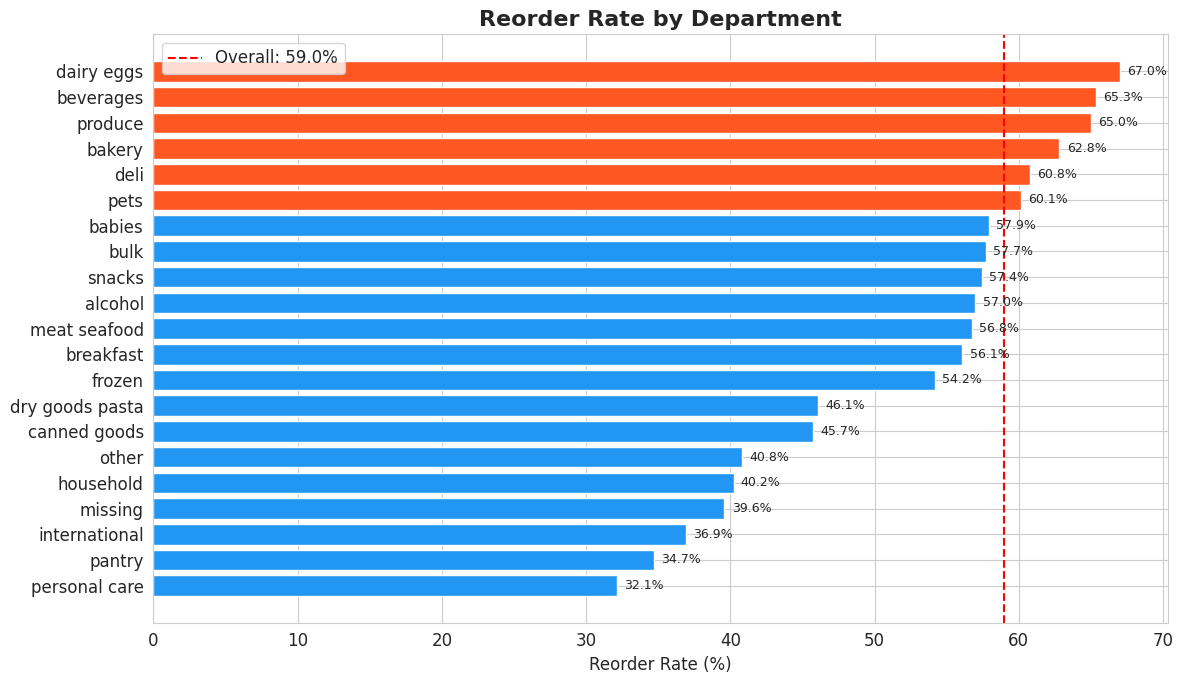

In [ ]:
dept_reorder = df.groupby('department').agg(
    total_items=('reordered', 'count'),
    reorder_rate=('reordered', 'mean')
).sort_values('reorder_rate', ascending=True).reset_index()

plt.figure(figsize=(12, 7))
colors = ['#FF5722' if x >= 0.6 else '#2196F3' for x in dept_reorder['reorder_rate']]
plt.barh(dept_reorder['department'], dept_reorder['reorder_rate'] * 100, color=colors, edgecolor='white')
plt.title('Reorder Rate by Department', fontsize=16, fontweight='bold')
plt.xlabel('Reorder Rate (%)')
plt.axvline(x=df['reordered'].mean()*100, color='red', linestyle='--', label=f"Overall: {df['reordered'].mean()*100:.1f}%")
plt.legend()

for i, v in enumerate(dept_reorder['reorder_rate']):
    plt.text(v*100 + 0.5, i, f'{v*100:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.show()

User stats: (206209, 5)
   user_id  total_orders  avg_basket_size  avg_days_between  reorder_rate
0        1            10         5.900000         20.259259      0.694915
1        2            14        13.928571         15.967033      0.476923
2        3            12         7.333333         11.487179      0.625000
3        4             5         3.600000         15.357143      0.055556
4        5             4         9.250000         14.500000      0.378378


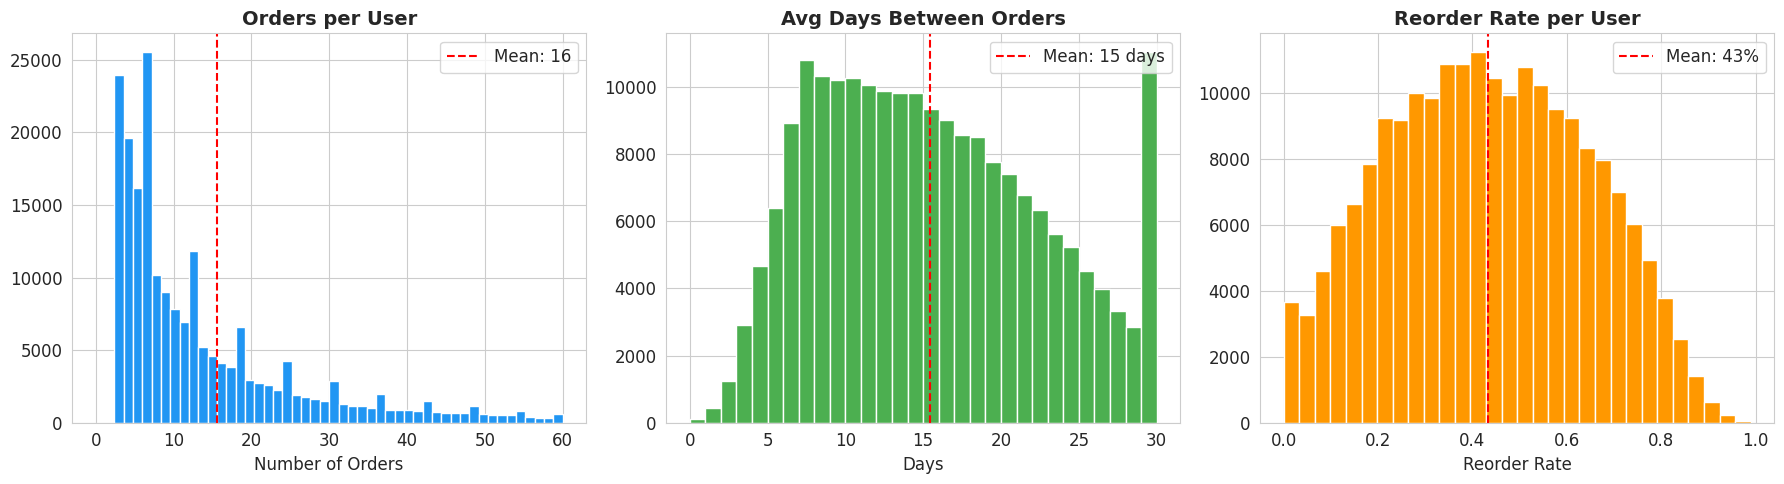

In [ ]:
# Calculate user stats separately
user_orders = df.groupby('user_id')['order_id'].nunique().reset_index(name='total_orders')
user_items = df.groupby(['user_id', 'order_id']).size().groupby('user_id').mean().reset_index(name='avg_basket_size')
user_days = df.groupby('user_id')['days_since_prior_order'].mean().reset_index(name='avg_days_between')
user_reorder = df.groupby('user_id')['reordered'].mean().reset_index(name='reorder_rate')

# Merge all
user_stats = user_orders.merge(user_items, on='user_id') \
                         .merge(user_days, on='user_id') \
                         .merge(user_reorder, on='user_id')

print(f"User stats: {user_stats.shape}")
print(user_stats.head())

# Plot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(user_stats['total_orders'], bins=50, color='#2196F3', edgecolor='white', range=(0, 60))
axes[0].axvline(user_stats['total_orders'].mean(), color='red', linestyle='--', label=f"Mean: {user_stats['total_orders'].mean():.0f}")
axes[0].set_title('Orders per User', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Number of Orders')
axes[0].legend()

axes[1].hist(user_stats['avg_days_between'].dropna(), bins=30, color='#4CAF50', edgecolor='white')
axes[1].axvline(user_stats['avg_days_between'].mean(), color='red', linestyle='--', label=f"Mean: {user_stats['avg_days_between'].mean():.0f} days")
axes[1].set_title('Avg Days Between Orders', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Days')
axes[1].legend()

axes[2].hist(user_stats['reorder_rate'], bins=30, color='#FF9800', edgecolor='white')
axes[2].axvline(user_stats['reorder_rate'].mean(), color='red', linestyle='--', label=f"Mean: {user_stats['reorder_rate'].mean()*100:.0f}%")
axes[2].set_title('Reorder Rate per User', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Reorder Rate')
axes[2].legend()

plt.tight_layout()
plt.show()

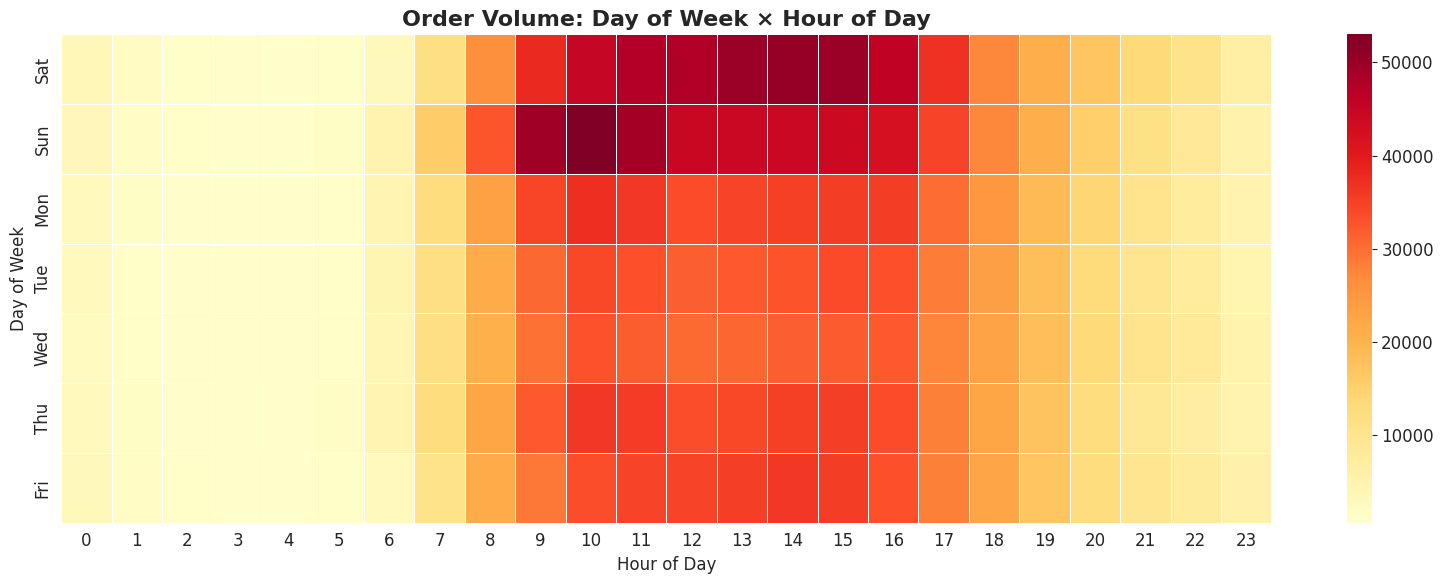

In [ ]:
heatmap_data = df.groupby(['order_dow', 'order_hour_of_day'])['order_id'].nunique().reset_index()
heatmap_pivot = heatmap_data.pivot(index='order_dow', columns='order_hour_of_day', values='order_id')

day_labels = ['Sat', 'Sun', 'Mon', 'Tue', 'Wed', 'Thu', 'Fri']
heatmap_pivot.index = day_labels

plt.figure(figsize=(16, 6))
sns.heatmap(heatmap_pivot, cmap='YlOrRd', annot=False, fmt=',', linewidths=0.5)
plt.title('Order Volume: Day of Week × Hour of Day', fontsize=16, fontweight='bold')
plt.xlabel('Hour of Day')
plt.ylabel('Day of Week')
plt.tight_layout()
plt.show()


In [ ]:
from itertools import combinations
from collections import Counter

# Get top 100 products by order count
top100_ids = df.groupby('product_id')['order_id'].nunique().nlargest(100).index
df_top = df[df['product_id'].isin(top100_ids)]

print(f"Original: {df.shape[0]:,} rows")
print(f"Filtered (top 100 products): {df_top.shape[0]:,} rows")
print(f"Orders containing top 100 products: {df_top['order_id'].nunique():,}")

Original: 32,434,489 rows
Filtered (top 100 products): 7,483,881 rows
Orders containing top 100 products: 2,351,240


In [ ]:
# Get product names per order (only orders with 2+ top products)
order_prods = df_top.groupby('order_id')['product_name'].apply(set).reset_index()
order_prods['n_items'] = order_prods['product_name'].apply(len)
order_prods = order_prods[order_prods['n_items'] >= 2]

print(f"Orders with 2+ top products: {order_prods.shape[0]:,}")
print("Finding product pairs... (may take 1-2 minutes)")

# Count co-occurrences
pair_counts = Counter()
for _, row in order_prods.iterrows():
    for pair in combinations(sorted(row['product_name']), 2):
        pair_counts[pair] += 1

print(f"Unique pairs found: {len(pair_counts):,}")
print("Done!")

Orders with 2+ top products: 1,658,656
Finding product pairs... (may take 1-2 minutes)
Unique pairs found: 4,945
Done!


In [ ]:
total_orders = df['order_id'].nunique()

# Product frequency (how many orders contain each product)
product_freq = df_top.groupby('product_name')['order_id'].nunique().to_dict()

# Build association rules table
rules = []
for (prod_a, prod_b), count in pair_counts.most_common(50):
    support = count / total_orders
    freq_a = product_freq[prod_a]
    freq_b = product_freq[prod_b]
    confidence_ab = count / freq_a  # P(B|A)
    confidence_ba = count / freq_b  # P(A|B)
    lift = support / ((freq_a / total_orders) * (freq_b / total_orders))

    rules.append({
        'Product A': prod_a,
        'Product B': prod_b,
        'Co-occur Count': count,
        'Support': round(support, 4),
        'Confidence (A→B)': round(confidence_ab, 4),
        'Confidence (B→A)': round(confidence_ba, 4),
        'Lift': round(lift, 2)
    })

rules_df = pd.DataFrame(rules)
print("=== Top 20 Product Pairs by Co-occurrence ===\n")
print(rules_df.head(20).to_string(index=False))

=== Top 20 Product Pairs by Co-occurrence ===

             Product A            Product B  Co-occur Count  Support  Confidence (A→B)  Confidence (B→A)  Lift
Bag of Organic Bananas Organic Hass Avocado           62341   0.0194            0.1643            0.2919  2.47
Bag of Organic Bananas Organic Strawberries           61628   0.0192            0.1624            0.2328  1.97
                Banana Organic Strawberries           56156   0.0175            0.1188            0.2122  1.44
                Banana      Organic Avocado           53395   0.0166            0.1130            0.3020  2.05
                Banana Organic Baby Spinach           51395   0.0160            0.1088            0.2124  1.45
Bag of Organic Bananas Organic Baby Spinach           50372   0.0157            0.1328            0.2082  1.76
                Banana         Strawberries           41232   0.0128            0.0873            0.2884  1.96
                Banana          Large Lemon           40880   0.0

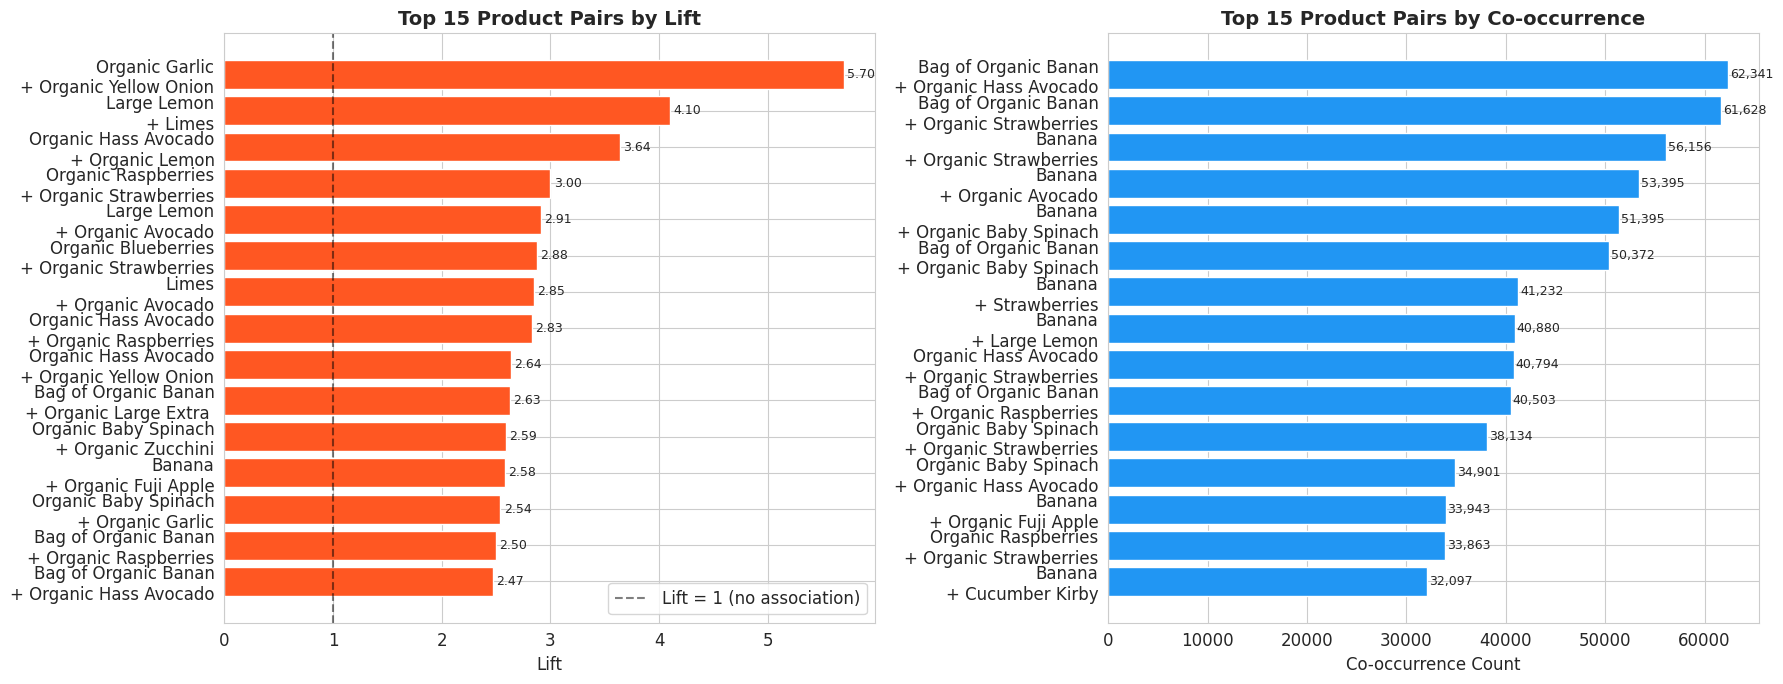

In [ ]:
top_lift = rules_df.nlargest(15, 'Lift')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# Chart 1: Top 15 by Lift
labels = top_lift['Product A'].str[:20] + '\n+ ' + top_lift['Product B'].str[:20]
ax1.barh(labels[::-1], top_lift['Lift'][::-1], color='#FF5722', edgecolor='white')
ax1.axvline(x=1.0, color='black', linestyle='--', alpha=0.5, label='Lift = 1 (no association)')
ax1.set_title('Top 15 Product Pairs by Lift', fontsize=14, fontweight='bold')
ax1.set_xlabel('Lift')
ax1.legend()
for i, v in enumerate(top_lift['Lift'][::-1]):
    ax1.text(v + 0.03, i, f'{v:.2f}', va='center', fontsize=9)

# Chart 2: Top 15 by Co-occurrence
top_count = rules_df.nlargest(15, 'Co-occur Count')
labels2 = top_count['Product A'].str[:20] + '\n+ ' + top_count['Product B'].str[:20]
ax2.barh(labels2[::-1], top_count['Co-occur Count'][::-1], color='#2196F3', edgecolor='white')
ax2.set_title('Top 15 Product Pairs by Co-occurrence', fontsize=14, fontweight='bold')
ax2.set_xlabel('Co-occurrence Count')
for i, v in enumerate(top_count['Co-occur Count'][::-1]):
    ax2.text(v + 200, i, f'{v:,}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

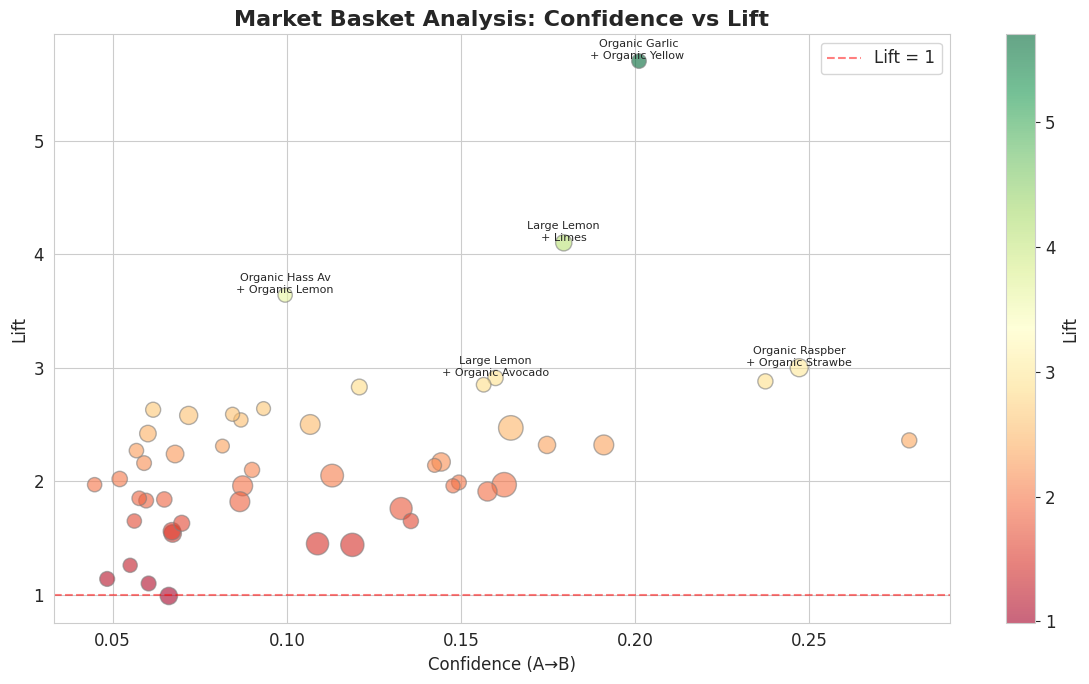

Bubble size = Co-occurrence count
Green/top-right = Strong cross-sell candidates


In [ ]:
plt.figure(figsize=(12, 7))
scatter = plt.scatter(rules_df['Confidence (A→B)'], rules_df['Lift'],
                      s=rules_df['Co-occur Count']/200, alpha=0.6, c=rules_df['Lift'], cmap='RdYlGn', edgecolors='gray')

# Label top pairs
for _, row in rules_df.nlargest(5, 'Lift').iterrows():
    plt.annotate(f"{row['Product A'][:15]}\n+ {row['Product B'][:15]}",
                 xy=(row['Confidence (A→B)'], row['Lift']),
                 fontsize=8, ha='center', va='bottom')

plt.axhline(y=1.0, color='red', linestyle='--', alpha=0.5, label='Lift = 1')
plt.colorbar(scatter, label='Lift')
plt.title('Market Basket Analysis: Confidence vs Lift', fontsize=16, fontweight='bold')
plt.xlabel('Confidence (A→B)')
plt.ylabel('Lift')
plt.legend()
plt.tight_layout()
plt.show()

print("Bubble size = Co-occurrence count")
print("Green/top-right = Strong cross-sell candidates")

In [ ]:
# user_stats already created from Cell 17
print(user_stats.describe().round(2))

         user_id  total_orders  avg_basket_size  avg_days_between  \
count  206209.00     206209.00        206209.00         206209.00   
mean   103105.00         15.59             9.95             15.47   
std     59527.56         16.65             5.86              7.21   
min         1.00          3.00             1.00              0.00   
25%     51553.00          5.00             5.74              9.55   
50%    103105.00          9.00             8.93             14.69   
75%    154657.00         19.00            13.00             20.72   
max    206209.00         99.00            70.25             30.00   

       reorder_rate  
count     206209.00  
mean           0.43  
std            0.21  
min            0.00  
25%            0.27  
50%            0.43  
75%            0.60  
max            0.99  


In [ ]:
# Segment by order frequency
user_stats['freq_segment'] = pd.cut(
    user_stats['total_orders'],
    bins=[0, 5, 15, 30, 100],
    labels=['Light (1-5)', 'Regular (6-15)', 'Frequent (16-30)', 'Heavy (31+)']
)

# Segment by basket size
user_stats['basket_segment'] = pd.cut(
    user_stats['avg_basket_size'],
    bins=[0, 5, 10, 20, 200],
    labels=['Small (1-5)', 'Medium (6-10)', 'Large (11-20)', 'Bulk (21+)']
)

# Combined segment summary
segment_summary = user_stats.groupby('freq_segment').agg(
    user_count=('user_id', 'count'),
    avg_basket=('avg_basket_size', 'mean'),
    avg_reorder=('reorder_rate', 'mean'),
    avg_days=('avg_days_between', 'mean')
).round(2)

segment_summary['user_pct'] = (segment_summary['user_count'] / segment_summary['user_count'].sum() * 100).round(1)
print("=== Customer Segments by Order Frequency ===\n")
print(segment_summary)

=== Customer Segments by Order Frequency ===

                  user_count  avg_basket  avg_reorder  avg_days  user_pct
freq_segment                                                             
Light (1-5)            59741        9.65         0.25     19.46      29.0
Regular (6-15)         81172        9.94         0.42     16.76      39.4
Frequent (16-30)       37587       10.18         0.57     12.31      18.2
Heavy (31+)            27709       10.32         0.70      7.37      13.4


/tmp/ipykernel_10019/1203265847.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  segment_summary = user_stats.groupby('freq_segment').agg(


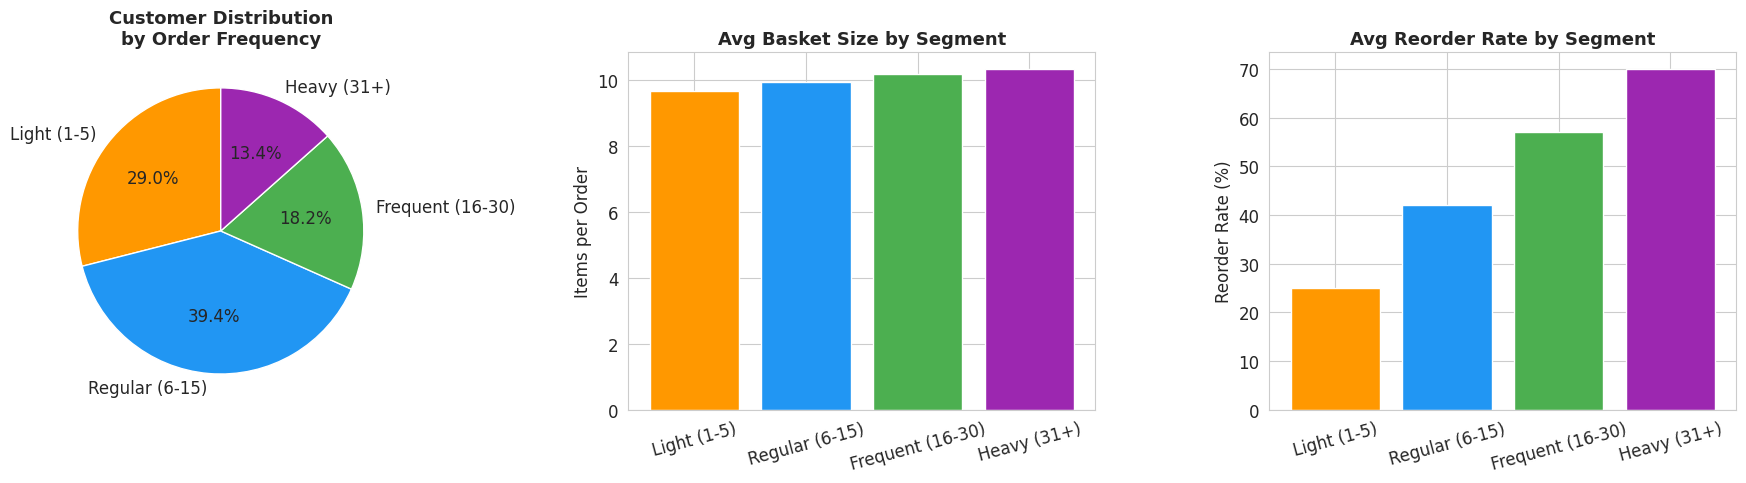

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Pie chart - segment distribution
axes[0].pie(segment_summary['user_count'], labels=segment_summary.index, autopct='%1.1f%%',
            colors=['#FF9800', '#2196F3', '#4CAF50', '#9C27B0'], startangle=90)
axes[0].set_title('Customer Distribution\nby Order Frequency', fontsize=13, fontweight='bold')

# Bar - avg basket size by segment
axes[1].bar(segment_summary.index, segment_summary['avg_basket'], color=['#FF9800', '#2196F3', '#4CAF50', '#9C27B0'])
axes[1].set_title('Avg Basket Size by Segment', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Items per Order')
axes[1].tick_params(axis='x', rotation=15)

# Bar - avg reorder rate by segment
axes[2].bar(segment_summary.index, segment_summary['avg_reorder']*100, color=['#FF9800', '#2196F3', '#4CAF50', '#9C27B0'])
axes[2].set_title('Avg Reorder Rate by Segment', fontsize=13, fontweight='bold')
axes[2].set_ylabel('Reorder Rate (%)')
axes[2].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

In [ ]:
from google.colab import files

EXPORT_PATH = '/content/exports/'
import os
os.makedirs(EXPORT_PATH, exist_ok=True)

# 1. Main analytical table
np.random.seed(42)
sample_users_pbi = np.random.choice(df['user_id'].unique(), size=50000, replace=False)
df_pbi = df[df['user_id'].isin(sample_users_pbi)]
df_pbi.to_csv(EXPORT_PATH + 'fact_order_products.csv', index=False)
print(f"1. fact_order_products.csv: {df_pbi.shape[0]:,} rows")

# 2. User stats
user_stats.to_csv(EXPORT_PATH + 'dim_user_stats.csv', index=False)
print(f"2. dim_user_stats.csv: {user_stats.shape[0]:,} rows")

# 3. Market basket rules
rules_df.to_csv(EXPORT_PATH + 'market_basket_rules.csv', index=False)
print(f"3. market_basket_rules.csv: {rules_df.shape[0]:,} rows")

# 4. Department summary
dept_summary = df.groupby('department').agg(
    total_orders=('order_id', 'nunique'),
    total_items=('product_id', 'count'),
    reorder_rate=('reordered', 'mean'),
    unique_products=('product_id', 'nunique')
).round(4).reset_index()
dept_summary.to_csv(EXPORT_PATH + 'dept_summary.csv', index=False)
print(f"4. dept_summary.csv: {dept_summary.shape[0]} rows")

# 5. Order patterns
hourly_daily = df.groupby(['order_dow', 'order_hour_of_day'])['order_id'].nunique().reset_index()
hourly_daily.columns = ['order_dow', 'order_hour', 'total_orders']
hourly_daily.to_csv(EXPORT_PATH + 'order_patterns.csv', index=False)
print(f"5. order_patterns.csv: {hourly_daily.shape[0]} rows")

print("\n--- Downloading files ---")
for f in os.listdir(EXPORT_PATH):
    print(f"Downloading: {f}")
    files.download(EXPORT_PATH + f)

NameError: name 'df' is not defined